# Neural external-field pseudo-likelihood for DGL Fraud Yelp

We fit the three-relation Ising-type model

$$
\mathbb P_{\beta,\theta}(\sigma\mid X,G)
\propto
\exp\left\{
\sum_{r=1}^3 \beta_r \sum_{(i,j)\in E_r}\sigma_i\sigma_j
+
2\sum_{i=1}^n \sigma_i b_\theta(X_i)
\right\},
\qquad \sigma_i\in\{-1,1\}.
$$

Here \(b_\theta:\mathbb R^d\to\mathbb R\) is a neural network. This replaces the linear external field \(X_i^\top\gamma\) by a nonlinear learned field \(b_\theta(X_i)\).

The full likelihood is not used, since the partition function is intractable. Instead, we fit the pseudo-likelihood. Define

$$
S_{ir}=\sum_{j:(j,i)\in E_r}\sigma_j,
\qquad r=1,2,3.
$$

Then

$$
h_i
=
\sum_{r=1}^3 \beta_r S_{ir}
+
2b_\theta(X_i),
$$

and

$$
\mathbb P_{\beta,\theta}(\sigma_i=1\mid \sigma_{-i},X,G)
=
\operatorname{logit}^{-1}(2h_i).
$$

Thus fitting the pseudo-likelihood is just binary cross-entropy training with logits \(2h_i\).


In [ ]:
# If needed, install dependencies first. Pick the DGL wheel matching your PyTorch version.
# %pip install -q scikit-learn pandas matplotlib
# %pip install -q dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html


In [1]:
import math
import random
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

import matplotlib.pyplot as plt

import dgl
from dgl.data import FraudYelpDataset


SEED = 717

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Load the dataset

DGL's Fraud Yelp dataset has three edge relations. We use

$$
(\beta_1,\beta_2,\beta_3)
=
(\beta_{\text{net\_rur}},\beta_{\text{net\_rsr}},\beta_{\text{net\_rtr}}).
$$

The binary labels are converted by

$$
\sigma_i=2y_i-1.
$$


In [2]:
dataset = FraudYelpDataset(
    random_seed=SEED,
    train_size=0.7,
    val_size=0.1,
    verbose=True,
)

g = dataset[0]

print(g)
print("node types:", g.ntypes)
print("edge types:", g.etypes)
print("canonical edge types:", g.canonical_etypes)


Done loading data from cached files.
Graph(num_nodes={'review': 45954},
      num_edges={('review', 'net_rsr', 'review'): 6805486, ('review', 'net_rtr', 'review'): 1147232, ('review', 'net_rur', 'review'): 98630},
      metagraph=[('review', 'review', 'net_rsr'), ('review', 'review', 'net_rtr'), ('review', 'review', 'net_rur')])
node types: ['review']
edge types: ['net_rsr', 'net_rtr', 'net_rur']
canonical edge types: [('review', 'net_rsr', 'review'), ('review', 'net_rtr', 'review'), ('review', 'net_rur', 'review')]


In [3]:
def get_node_data(g, key, ntype=None):
    if ntype is None:
        if len(g.ntypes) != 1:
            raise ValueError("Pass ntype explicitly when the graph has multiple node types.")
        ntype = g.ntypes[0]

    value = g.ndata[key]
    if isinstance(value, dict):
        return value[ntype]
    return value


ntype = g.ntypes[0]

X_raw = get_node_data(g, "feature", ntype).float()
y01 = get_node_data(g, "label", ntype).long()

train_mask = get_node_data(g, "train_mask", ntype).bool()
val_mask = get_node_data(g, "val_mask", ntype).bool()
test_mask = get_node_data(g, "test_mask", ntype).bool()

sigma_all = 2.0 * y01.float() - 1.0

summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "n": [
        int(train_mask.sum()),
        int(val_mask.sum()),
        int(test_mask.sum()),
        int(y01.numel()),
    ],
    "positives_label_1": [
        int(y01[train_mask].sum()),
        int(y01[val_mask].sum()),
        int(y01[test_mask].sum()),
        int(y01.sum()),
    ],
})

summary["positive_rate"] = summary["positives_label_1"] / summary["n"]
summary


,split,n,positives_label_1,positive_rate
0,train,32167,4726,0.146921
1,validation,4595,651,0.141676
2,test,9192,1300,0.141427
3,all,45954,6677,0.145297


In [4]:
EDGE_TYPES = ["net_rur", "net_rsr", "net_rtr"]

BETA_LABELS = [
    "beta_1: net_rur",
    "beta_2: net_rsr",
    "beta_3: net_rtr",
]

missing = [e for e in EDGE_TYPES if e not in g.etypes]
if missing:
    raise ValueError(f"Missing expected edge types: {missing}. Present edge types: {g.etypes}")

for etype in EDGE_TYPES:
    print(f"{etype:8s}: {g.num_edges(etype=etype):,} directed edges")


net_rur : 98,630 directed edges
net_rsr : 6,805,486 directed edges
net_rtr : 1,147,232 directed edges


## Standardize node features

The neural network receives standardized features. The mean and standard deviation are computed from the training nodes only.

Unlike the previous linear notebook, we do not add an intercept column to \(X\). The neural net has its own bias terms.


In [5]:
def standardize_with_train_stats(X, train_mask, eps=1e-12):
    X = X.float()
    mean = X[train_mask].mean(dim=0)
    std = X[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
    X_std = (X - mean) / std
    return X_std, mean, std


X, X_mean, X_std = standardize_with_train_stats(X_raw, train_mask)

print("raw feature shape:", tuple(X_raw.shape))
print("standardized feature shape:", tuple(X.shape))


raw feature shape: (45954, 32)
standardized feature shape: (45954, 32)


## Construct the local relation fields \(S_{ir}\)

For fair train/validation/test evaluation, we use only training labels when forming neighbor sums. That means

$$
\sigma_j^{\mathrm{obs}}
=
\begin{cases}
\sigma_j, & j\in\mathcal T,\\
0, & j\notin\mathcal T.
\end{cases}
$$

Then

$$
S_{ir}=\sum_{j:(j,i)\in E_r}\sigma_j^{\mathrm{obs}}.
$$

This avoids using validation/test labels as covariates. If you want the oracle diagnostic pseudo-likelihood, change `SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS` to all `True`.


In [6]:
SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = train_mask
# SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = torch.ones_like(train_mask, dtype=torch.bool)  # oracle diagnostic only

# To match the displayed Gibbs model, use "none".
# If raw degrees cause numerical saturation, try "degree" or "sqrt_degree".
# Those are degree-normalized variants of the displayed model.
NEIGHBOR_NORMALIZATION = "none"  # one of {"none", "degree", "sqrt_degree"}


@torch.no_grad()
def compute_relation_neighbor_sums(g, sigma_source, edge_types, normalize="none", device=None):
    if device is None:
        device = sigma_source.device

    sigma_source = sigma_source.to(device).float()
    n = sigma_source.numel()
    columns = []

    for etype in edge_types:
        src, dst = g.edges(etype=etype)
        src = src.to(device)
        dst = dst.to(device)

        out = torch.zeros(n, dtype=torch.float32, device=device)
        out.index_add_(0, dst, sigma_source[src])

        if normalize in {"degree", "sqrt_degree"}:
            deg = torch.zeros(n, dtype=torch.float32, device=device)
            deg.index_add_(0, dst, torch.ones(dst.numel(), dtype=torch.float32, device=device))

            if normalize == "degree":
                out = out / deg.clamp_min(1.0)
            else:
                out = out / deg.clamp_min(1.0).sqrt()

        elif normalize == "none":
            pass

        else:
            raise ValueError("normalize must be one of {'none', 'degree', 'sqrt_degree'}")

        columns.append(out)

    return torch.stack(columns, dim=1)


sigma_source = torch.zeros_like(sigma_all)
sigma_source[SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS] = sigma_all[SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS]

S_raw = compute_relation_neighbor_sums(
    g,
    sigma_source=sigma_source,
    edge_types=EDGE_TYPES,
    normalize=NEIGHBOR_NORMALIZATION,
    device=device,
).cpu()

pd.DataFrame(S_raw[train_mask].numpy(), columns=EDGE_TYPES).describe().T


,count,mean,std,min,25%,50%,75%,max
net_rur,32167.0,-1.448379,3.046559,-36.0,-2.0,0.0,0.0,5.0
net_rsr,32167.0,-74.249199,51.118523,-215.0,-110.0,-70.0,-31.0,72.0
net_rtr,32167.0,-12.244598,9.326547,-70.0,-17.0,-11.0,-6.0,18.0


For numerical stability, we scale each relation field by its training-set standard deviation:

$$
\widetilde S_{ir}=S_{ir}/a_r.
$$

The model is trained in the scaled parameterization. After training, the original-scale coefficient is

$$
\widehat\beta_r^{\mathrm{original}}
=
\widehat\beta_r^{\mathrm{scaled}}/a_r.
$$


In [7]:
eps = 1e-12
S_scale = S_raw[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
S = S_raw / S_scale

pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "S_train_std": S_scale.numpy(),
})


,edge_type,S_train_std
0,net_rur,3.046913
1,net_rsr,51.116573
2,net_rtr,9.326660


## Neural external-field model

This is the main model:

$$
h_i
=
\sum_{r=1}^3 \beta_r \widetilde S_{ir}
+
2b_\theta(X_i),
\qquad
\operatorname{logit}\mathbb P(\sigma_i=1\mid\cdots)
=
2h_i.
$$

Both \(\beta\) and the neural-network weights \(\theta\) are learned jointly by backpropagation.


In [8]:
class NeuralExternalFieldMPLE(nn.Module):
    def __init__(self, n_features, n_relations=3, hidden=64, dropout=0.2):
        super().__init__()

        self.beta = nn.Parameter(torch.zeros(n_relations))

        self.field_net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def field(self, X):
        return self.field_net(X).squeeze(-1)

    def logits(self, S, X):
        b = self.field(X)
        h = S @ self.beta + 2.0 * b
        return 2.0 * h

    def forward(self, S, X):
        return self.logits(S, X)


## Training function

The minimized loss is

$$
\frac{1}{|\mathcal T|}
\sum_{i\in\mathcal T}
\operatorname{BCE}\left(
y_i,
\operatorname{logit}^{-1}
\left[
2\left(
\sum_{r=1}^3\beta_r \widetilde S_{ir}
+
2b_\theta(X_i)
\right)
\right]
\right)
+
\text{regularization}.
$$

The option `USE_POS_WEIGHT=True` changes the loss to handle class imbalance. This may improve classification metrics, but it is no longer the ordinary pseudo-likelihood objective.


In [9]:
def compute_metrics(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    pred = (score >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])

    out = {
        "threshold": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision_pos": precision_score(y_true, pred, zero_division=0),
        "recall_pos": recall_score(y_true, pred, zero_division=0),
        "f1_pos": f1_score(y_true, pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }

    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan

    return out


@torch.no_grad()
def predict_prob(model, S, X, device):
    model.eval()
    logits = model(S.to(device).float(), X.to(device).float())
    return torch.sigmoid(logits).cpu()


def select_threshold(y_true, score, objective="balanced_accuracy", n_grid=1001):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)

    thresholds = np.linspace(0.0, 1.0, n_grid)
    best_t = 0.5
    best_value = -np.inf

    for t in thresholds:
        pred = (score >= t).astype(int)

        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif objective == "f1":
            value = f1_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("objective must be 'balanced_accuracy' or 'f1'")

        if value > best_value:
            best_value = value
            best_t = float(t)

    return best_t, best_value


def evaluate_splits(model, S, X, y01, masks, threshold, device):
    prob = predict_prob(model, S, X, device).numpy()
    y_np = y01.numpy().astype(int)

    rows = []
    for name, mask in masks.items():
        idx = mask.numpy().astype(bool)
        row = compute_metrics(y_np[idx], prob[idx], threshold)
        row["split"] = name
        rows.append(row)

    return pd.DataFrame(rows)


In [10]:
def train_neural_mple(
    S,
    X,
    y01,
    train_mask,
    val_mask,
    hidden=64,
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    l2_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=False,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_dev = S.to(device).float()
    X_dev = X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev = train_mask.to(device).bool()
    val_mask_dev = val_mask.to(device).bool()

    model = NeuralExternalFieldMPLE(
        n_features=X.shape[1],
        n_relations=S.shape[1],
        hidden=hidden,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value = None
        pos_weight = None

    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)

        train_loss_data = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev],
            y_dev[train_mask_dev],
            pos_weight=pos_weight,
        )

        beta_penalty = 0.5 * l2_beta * (model.beta @ model.beta)
        train_loss = train_loss_data + beta_penalty

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)

            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev],
                y_dev[val_mask_dev],
            )

            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev],
                y_dev[train_mask_dev],
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
            "beta_norm": float(model.beta.detach().norm().item()),
        })

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f} "
                f"beta={model.beta.detach().cpu().numpy()}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    return model, history_df, {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
    }


## Fit the neural pseudo-likelihood model


In [11]:
USE_POS_WEIGHT = False

model, history_df, fit_info = train_neural_mple(
    S=S,
    X=X,
    y01=y01,
    train_mask=train_mask,
    val_mask=val_mask,
    hidden=64,
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    l2_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=USE_POS_WEIGHT,
    device=device,
)

fit_info


epoch=   0 train_loss=0.65414 val_loss=0.65437 beta=[0.001 0.001 0.001]
epoch=  50 train_loss=0.35201 val_loss=0.34973 beta=[0.03904318 0.02057381 0.01689629]
epoch= 100 train_loss=0.32295 val_loss=0.32409 beta=[0.07579616 0.03286953 0.02267437]
epoch= 150 train_loss=0.30378 val_loss=0.31017 beta=[0.11149278 0.04654677 0.02904472]
epoch= 200 train_loss=0.29065 val_loss=0.30053 beta=[0.14620735 0.06051439 0.03549405]
epoch= 250 train_loss=0.28153 val_loss=0.29311 beta=[0.18029982 0.07405287 0.0414635 ]
epoch= 300 train_loss=0.27382 val_loss=0.28656 beta=[0.21370368 0.08666196 0.04647175]
epoch= 350 train_loss=0.26722 val_loss=0.28113 beta=[0.24641241 0.09806168 0.05027393]
epoch= 400 train_loss=0.26084 val_loss=0.27623 beta=[0.27847394 0.10820724 0.05313006]
epoch= 450 train_loss=0.25462 val_loss=0.27172 beta=[0.30988652 0.1172189  0.05515386]
epoch= 500 train_loss=0.24821 val_loss=0.26696 beta=[0.34069335 0.12538345 0.05675661]
epoch= 550 train_loss=0.24115 val_loss=0.26136 beta=[0.370

{'best_epoch': 991, 'best_val_loss': 0.22628085315227509, 'pos_weight': None}

In [12]:
history_df.tail()


,epoch,train_loss,val_loss,beta_norm
995,995,0.196080,0.226592,0.638319
996,996,0.196040,0.226594,0.638822
997,997,0.196006,0.226601,0.639323
998,998,0.195919,0.226598,0.639821
999,999,0.195836,0.226600,0.640321


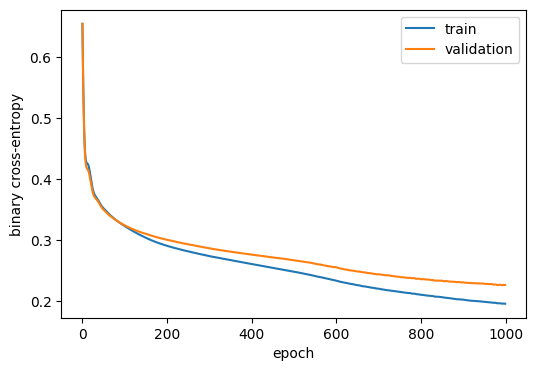

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy")
plt.legend()
plt.show()


## Estimated \(\beta\)'s

The displayed scaled estimates are the parameters used internally with \(\widetilde S\). The original-scale estimates divide by the relation-specific scale factor.


In [14]:
with torch.no_grad():
    beta_scaled = model.beta.detach().cpu()
    beta_original_scale = beta_scaled / S_scale.cpu()

beta_df = pd.DataFrame({
    "parameter": BETA_LABELS,
    "estimate_on_scaled_S": beta_scaled.numpy(),
    "estimate_original_S_scale": beta_original_scale.numpy(),
})

beta_df


,parameter,estimate_on_scaled_S,estimate_original_S_scale
0,beta_1: net_rur,0.610766,0.200454
1,beta_2: net_rsr,0.166961,0.003266
2,beta_3: net_rtr,0.063041,0.006759


## Learned neural field \(b_\theta(X_i)\)

The following computes the learned scalar external field at each node. This is the nonlinear analogue of \(X_i^\top\gamma\).


In [15]:
@torch.no_grad()
def compute_learned_field(model, X, device):
    model.eval()
    b = model.field(X.to(device).float())
    return b.detach().cpu()


b_hat = compute_learned_field(model, X, device)

field_summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "mean_b_hat": [
        float(b_hat[train_mask].mean()),
        float(b_hat[val_mask].mean()),
        float(b_hat[test_mask].mean()),
        float(b_hat.mean()),
    ],
    "std_b_hat": [
        float(b_hat[train_mask].std(unbiased=False)),
        float(b_hat[val_mask].std(unbiased=False)),
        float(b_hat[test_mask].std(unbiased=False)),
        float(b_hat.std(unbiased=False)),
    ],
})

field_summary


,split,mean_b_hat,std_b_hat
0,train,-0.464235,0.511497
1,validation,-0.456195,0.500681
2,test,-0.463602,0.498998
3,all,-0.463305,0.507950


In [16]:
pd.DataFrame({
    "y": y01.numpy(),
    "sigma": sigma_all.numpy(),
    "b_hat": b_hat.numpy(),
    "train": train_mask.numpy(),
    "validation": val_mask.numpy(),
    "test": test_mask.numpy(),
}).groupby("y")["b_hat"].describe()


,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,39277.0,-0.571715,0.439015,-3.276031,-0.819076,-0.533479,-0.277760,1.157233
1,6677.0,0.174415,0.407725,-1.649263,-0.093237,0.163774,0.432055,1.677145


## Prediction and evaluation

We report metrics at threshold \(0.5\), and also at a threshold chosen on the validation set to maximize balanced accuracy.


In [17]:
masks = {
    "train": train_mask,
    "validation": val_mask,
    "test": test_mask,
}

metrics_05 = evaluate_splits(
    model=model,
    S=S,
    X=X,
    y01=y01,
    masks=masks,
    threshold=0.5,
    device=device,
)

metrics_05


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.5,32167,0.146921,0.924053,0.774903,0.874877,0.563690,0.685626,27060,381,2062,2664,0.948356,0.822034,train
1,0.5,4595,0.141676,0.910120,0.739228,0.787440,0.500768,0.612207,3856,88,325,326,0.921814,0.724953,validation
2,0.5,9192,0.141427,0.912859,0.743325,0.804640,0.506923,0.621992,7732,160,641,659,0.921546,0.734008,test


In [18]:
prob = predict_prob(model, S, X, device).numpy()
y_np = y01.numpy().astype(int)

val_idx = val_mask.numpy().astype(bool)
best_t_balacc, best_val_balacc = select_threshold(
    y_true=y_np[val_idx],
    score=prob[val_idx],
    objective="balanced_accuracy",
)

best_t_f1, best_val_f1 = select_threshold(
    y_true=y_np[val_idx],
    score=prob[val_idx],
    objective="f1",
)

print("Best validation threshold for balanced accuracy:", best_t_balacc, "value:", best_val_balacc)
print("Best validation threshold for F1:", best_t_f1, "value:", best_val_f1)


Best validation threshold for balanced accuracy: 0.149 value: 0.8428420311394859
Best validation threshold for F1: 0.34600000000000003 value: 0.6635145784081954


In [19]:
metrics_val_balacc = evaluate_splits(
    model=model,
    S=S,
    X=X,
    y01=y01,
    masks=masks,
    threshold=best_t_balacc,
    device=device,
)

metrics_val_balacc


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.149,32167,0.146921,0.858084,0.874610,0.509667,0.898011,0.650272,23358,4083,482,4244,0.948356,0.822034,train
1,0.149,4595,0.141676,0.836997,0.842842,0.459370,0.850998,0.596661,3292,652,97,554,0.921814,0.724953,validation
2,0.149,9192,0.141427,0.842363,0.839127,0.467874,0.834615,0.599613,6658,1234,215,1085,0.921546,0.734008,test


## Inspect the local field decomposition

For each node,

$$
h_i
=
\underbrace{\sum_{r=1}^3\beta_r\widetilde S_{ir}}_{\text{graph interaction field}}
+
\underbrace{2b_\theta(X_i)}_{\text{neural external field}}.
$$

The following cell stores these components.


In [20]:
@torch.no_grad()
def local_field_decomposition(model, S, X, device):
    model.eval()

    S_dev = S.to(device).float()
    X_dev = X.to(device).float()

    beta = model.beta.detach()
    graph_field = S_dev @ beta
    neural_field = 2.0 * model.field(X_dev)
    total_h = graph_field + neural_field
    prob = torch.sigmoid(2.0 * total_h)

    return pd.DataFrame({
        "graph_field": graph_field.cpu().numpy(),
        "neural_external_field_2b": neural_field.cpu().numpy(),
        "total_h": total_h.cpu().numpy(),
        "prob_label_1": prob.cpu().numpy(),
        "label": y01.numpy(),
        "train": train_mask.numpy(),
        "validation": val_mask.numpy(),
        "test": test_mask.numpy(),
    })


field_decomp_df = local_field_decomposition(model, S, X, device)
field_decomp_df.head()


,graph_field,neural_external_field_2b,total_h,prob_label_1,label,train,validation,test
0,-0.003266,-0.937499,-0.940766,0.132213,0,False,True,False
1,0.000000,-0.188526,-0.188526,0.406838,0,True,False,False
2,0.000000,-0.914893,-0.914893,0.138264,0,True,False,False
3,0.003266,-0.199028,-0.195762,0.403351,0,False,False,True
4,0.003493,-0.485083,-0.481590,0.276242,0,False,False,True


In [21]:
field_decomp_df.groupby("label")[[
    "graph_field",
    "neural_external_field_2b",
    "total_h",
    "prob_label_1",
]].describe()


graph_field                                                              \
            count      mean       std       min       25%       50%       75%   
label                                                                           
0         39277.0 -0.678903  0.673545 -8.074289 -0.831965 -0.511885 -0.283620   
1          6677.0 -0.246573  0.233441 -1.413425 -0.397034 -0.238345 -0.093949   

                neural_external_field_2b            ...   total_h            \
            max                    count      mean  ...       75%       max   
label                                               ...                       
0      0.356838                  39277.0 -1.143431  ... -1.152737  1.691317   
1      1.136266                   6677.0  0.348830  ...  0.656076  3.424296   

      prob_label_1                                                        \
             count      mean       std           min       25%       50%   
label                                                                      
0          39277.0  0.075665  0.115566  3.836806e-12  0.009025  0.030061   
1           6677.0  0.533834  0.285051  1.381044e-03  0.286300  0.549903   

                           
            75%       max  
label                      
0      0.090671  0.967157  
1      0.787873  0.998940  

[2 rows x 32 columns]

## Optional: fully neural local-field model

The previous model preserves the Gibbs form with three interpretable \(\beta\)'s and a nonlinear external field. A more flexible alternative is

$$
h_i=f_\theta(X_i,\widetilde S_{i1},\widetilde S_{i2},\widetilde S_{i3}).
$$

This is best interpreted as a neural pseudo-likelihood classifier. It generally does not correspond to an Ising model with interpretable \(\beta_1,\beta_2,\beta_3\).


In [22]:
class FullyNeuralLocalFieldMPLE(nn.Module):
    def __init__(self, n_features, n_relations=3, hidden=64, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_features + n_relations, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def logits(self, S, X):
        Z = torch.cat([S, X], dim=1)
        h = self.net(Z).squeeze(-1)
        return 2.0 * h

    def forward(self, S, X):
        return self.logits(S, X)


In [23]:
def train_fully_neural_mple(
    S,
    X,
    y01,
    train_mask,
    val_mask,
    hidden=64,
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=False,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_dev = S.to(device).float()
    X_dev = X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev = train_mask.to(device).bool()
    val_mask_dev = val_mask.to(device).bool()

    model = FullyNeuralLocalFieldMPLE(
        n_features=X.shape[1],
        n_relations=S.shape[1],
        hidden=hidden,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value = None
        pos_weight = None

    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)
        train_loss = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev],
            y_dev[train_mask_dev],
            pos_weight=pos_weight,
        )

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)

            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev],
                y_dev[val_mask_dev],
            )

            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev],
                y_dev[train_mask_dev],
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
        })

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    return model, history_df, {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
    }


In [24]:
# Uncomment this block to fit the fully neural local-field model.

# fully_neural_model, fully_neural_history, fully_neural_info = train_fully_neural_mple(
#     S=S,
#     X=X,
#     y01=y01,
#     train_mask=train_mask,
#     val_mask=val_mask,
#     hidden=64,
#     dropout=0.2,
#     lr=1e-3,
#     weight_decay=1e-4,
#     max_epochs=1000,
#     patience=100,
#     use_pos_weight=False,
#     device=device,
# )
#
# fully_neural_info


In [25]:
# Uncomment this block after fitting the fully neural model.

# prob_full = predict_prob(fully_neural_model, S, X, device).numpy()
# val_idx = val_mask.numpy().astype(bool)
#
# best_t_full, best_val_balacc_full = select_threshold(
#     y_true=y_np[val_idx],
#     score=prob_full[val_idx],
#     objective="balanced_accuracy",
# )
#
# evaluate_splits(
#     model=fully_neural_model,
#     S=S,
#     X=X,
#     y01=y01,
#     masks=masks,
#     threshold=best_t_full,
#     device=device,
# )


## Save fitted outputs


In [ ]:
# Edit ROW_NAME before running if you want a custom label in the CSV.
from pathlib import Path

ROW_NAME = "S_unweigh_neural"

# For Colab, set SAVE_TO_GOOGLE_DRIVE=True and edit GOOGLE_DRIVE_METRICS_CSV_PATH.
SAVE_TO_GOOGLE_DRIVE = False
GOOGLE_DRIVE_METRICS_CSV_PATH = "/content/drive/MyDrive/yelp_s_metrics.csv"

if SAVE_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    METRICS_CSV_PATH = Path(GOOGLE_DRIVE_METRICS_CSV_PATH)
else:
    METRICS_CSV_PATH = Path("script/yelp/yelp_s_metrics.csv") if Path("script/yelp").exists() else Path("yelp_s_metrics.csv")


def append_test_metric_row(row_name, metric_frames, extra_metadata, csv_path=METRICS_CSV_PATH):
    csv_path = Path(csv_path)
    row = {"row_name": row_name, **extra_metadata}

    for metric_set, frame in metric_frames.items():
        test_rows = frame.loc[frame["split"].astype(str).str.lower().eq("test")]
        if test_rows.empty:
            raise ValueError(f"No test split found in {metric_set}")

        test_row = test_rows.iloc[0]
        prefix = metric_set.replace(".", "_")
        for column, value in test_row.items():
            if column == "split":
                continue
            row[f"{prefix}_{column}"] = value

    saved = pd.DataFrame([row])
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    saved.to_csv(csv_path, mode="a", header=not csv_path.exists(), index=False)
    print(f"Saved 1 test metric row to {csv_path}")
    return saved


metric_frames = {
    "threshold_0.5": metrics_05,
    "threshold_val_balanced_accuracy": metrics_val_balacc,
}

run_metadata = {
    "notebook": "S_unweigh_neural.ipynb",
    "model_type": "neural_external_field_mple",
    "neighbor_normalization": NEIGHBOR_NORMALIZATION,
    "source_labels": "train_mask_only" if torch.equal(SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS, train_mask) else "custom",
    "selected_threshold_balanced_accuracy": best_t_balacc,
}

saved_metric_row = append_test_metric_row(ROW_NAME, metric_frames, run_metadata)
saved_metric_row


In [26]:
results = {
    "model_type": "neural_external_field_mple",
    "edge_types": EDGE_TYPES,
    "neighbor_normalization": NEIGHBOR_NORMALIZATION,
    "source_labels_for_neighbor_sums": (
        "train_mask_only"
        if torch.equal(SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS, train_mask)
        else "custom"
    ),
    "fit_info": fit_info,
    "beta_scaled": beta_scaled.numpy().tolist(),
    "beta_original_scale": beta_original_scale.numpy().tolist(),
    "threshold_05_metrics": metrics_05.to_dict(orient="records"),
    "threshold_val_balanced_accuracy": best_t_balacc,
    "threshold_val_balanced_accuracy_metrics": metrics_val_balacc.to_dict(orient="records"),
}

pd.Series(results)


,0
model_type,neural_external_field_mple
edge_types,"[net_rur, net_rsr, net_rtr]"
neighbor_normalization,none
source_labels_for_neighbor_sums,train_mask_only
fit_info,"{'best_epoch': 991, 'best_val_loss': 0.2262808..."
beta_scaled,"[0.6107662916183472, 0.1669614613056183, 0.063..."
beta_original_scale,"[0.20045414566993713, 0.003266288200393319, 0...."
threshold_05_metrics,"[{'threshold': 0.5, 'n': 32167, 'positive_rate..."
threshold_val_balanced_accuracy,0.149
threshold_val_balanced_accuracy_metrics,"[{'threshold': 0.149, 'n': 32167, 'positive_ra..."
